In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [2]:
class PayoffAllocationGame:

    def __init__(self, generator, observer, T, initial_values, initial_portfolio=100):

        self.generator = generator
        self.observer = observer
        self.T = T
        self.initial_portfolio = initial_portfolio
        self.portfolio = initial_portfolio
        self.previous_values = initial_values
        self.portfolio_development = np.array([])
        self.allocation = np.array([])
        self.allocation_development = np.array([])

        

    def play_turn(self):
        
        # get new values for next time step from generator
        values = self.generator.generate()

        # get portfolio allocation from observer
        allocation = self.observer.make_allocation()

        # calculate return
        returns = (values - self.previous_values) / self.previous_values

        # exempt cash position from returns
        weighted_avg_return = allocation[1:] * returns

        # update portfolio
        self.portfolio = self.portfolio * (1 + weighted_avg_return)

        # update monitoring
        self.portfolio_development = np.append(self.portfolio_development, self.portfolio)
        self.allocation_development = np.append(self.allocation_development, self.allocation)

        # update values
        self.previous_values = values
        

        print(f"Values: {values}, Allocation: {allocation}, Portfolio: {self.portfolio}")
        

    def observe(self, values):
        self.observer.observe(values)
        
    
    def play_game(self):
        
        for i in range(self.T):
            #print(f"Turn {i+1}:")
            self.observe(self.previous_values)
            self.play_turn()
            

        return self.portfolio
    
    
    


In [3]:
class LinearGenerator:

    def __init__(self, start=2):
        self.value = start

    def generate(self):
        value = self.value
        self.value += 1
        return value
    

In [4]:
lg = LinearGenerator()


In [5]:
class StaticObserver:

    def __init__(self, allocation=np.array([0.5,0.5])):
        
        self.allocation = allocation

    def observe(self, values):
        pass

    def make_allocation(self):
        return self.allocation
        

In [6]:
so = StaticObserver()


In [7]:
game = PayoffAllocationGame(lg, so, 10, 1)

terminal_portfolio = game.play_game()

Values: 2, Allocation: [0.5 0.5], Portfolio: [150.]
Values: 3, Allocation: [0.5 0.5], Portfolio: [187.5]
Values: 4, Allocation: [0.5 0.5], Portfolio: [218.75]
Values: 5, Allocation: [0.5 0.5], Portfolio: [246.09375]
Values: 6, Allocation: [0.5 0.5], Portfolio: [270.703125]
Values: 7, Allocation: [0.5 0.5], Portfolio: [293.26171875]
Values: 8, Allocation: [0.5 0.5], Portfolio: [314.20898438]
Values: 9, Allocation: [0.5 0.5], Portfolio: [333.8470459]
Values: 10, Allocation: [0.5 0.5], Portfolio: [352.394104]
Values: 11, Allocation: [0.5 0.5], Portfolio: [370.0138092]


In [8]:
game.portfolio_development

array([150.        , 187.5       , 218.75      , 246.09375   ,
       270.703125  , 293.26171875, 314.20898438, 333.8470459 ,
       352.394104  , 370.0138092 ])

In [9]:
import numpy as np
from tqdm import tqdm

class Experiment:
    """
    A class to run multiple iterations of a game simulation with configurable generators.

    Attributes:
        n_runs (int): Number of simulation runs.
        game_class (class): Class implementing the game logic.
        generator_class (class): Class implementing the generator logic.
        generator_params (dict): Parameters for the generator class.
        observer_class (class): Class implementing the observer logic.
        T (int): Number of time steps in the game.
        initial_values (dict): Initial values or parameters for the game.
        initial_portfolio (float): Starting portfolio value (default is 100).
    """

    def __init__(self, n_runs, game_class, generator_class, generator_params, observer_class, T, initial_values, initial_portfolio=100):
        """
        Initializes the Experiment with the specified parameters.

        Args:
            n_runs (int): Number of simulation runs.
            game_class (class): Class implementing the game logic.
            generator_class (class): Class implementing the generator logic.
            generator_params (dict): Parameters for the generator class.
            observer_class (class): Class implementing the observer logic.
            T (int): Number of time steps in the game.
            initial_values (dict): Initial values or parameters for the game.
            initial_portfolio (float, optional): Starting portfolio value. Default is 100.
        """
        self.n_runs = n_runs
        self.game_class = game_class
        self.generator_class = generator_class
        self.generator_params = generator_params
        self.observer_class = observer_class
        self.T = T
        self.initial_values = initial_values
        self.initial_portfolio = initial_portfolio

    def execute(self):
        """
        Executes the experiment by running the game multiple times.

        Returns:
            numpy.ndarray: An array containing the results of each run.
        """
        results = np.array([])  # Initialize an empty NumPy array to store results.

        for _ in tqdm(range(self.n_runs), desc="Running simulations"):
            # Instantiate the observer, generator, and game classes for each run.
            observer = self.observer_class()
            generator = self.generator_class(**self.generator_params)
            game = self.game_class(generator, observer, self.T, self.initial_values, self.initial_portfolio)

            # Execute the game and collect the result.
            result = game.play_game()
            
            # Append the result to the results array.
            results = np.append(results, result)

        return results

# Example usage
# Uncomment and replace with actual classes to test the functionality.
# experiment = Experiment(
#     n_runs=100,
#     game_class=GameClass,
#     generator_class=GaussianGenerator,
#     generator_params={"mu": 0, "sigma": 1},
#     observer_class=ObserverClass,
#     T=100,
#     initial_values={"param1": 0.5, "param2": 1.0},
#     initial_portfolio=100
# )
# results = experiment.execute()


In [10]:


experiment = Experiment(10, PayoffAllocationGame, LinearGenerator, {}, StaticObserver, 10, 1)

results = experiment.execute()

Running simulations: 100%|██████████| 10/10 [00:00<00:00, 1111.22it/s]

Values: 2, Allocation: [0.5 0.5], Portfolio: [150.]
Values: 3, Allocation: [0.5 0.5], Portfolio: [187.5]
Values: 4, Allocation: [0.5 0.5], Portfolio: [218.75]
Values: 5, Allocation: [0.5 0.5], Portfolio: [246.09375]
Values: 6, Allocation: [0.5 0.5], Portfolio: [270.703125]
Values: 7, Allocation: [0.5 0.5], Portfolio: [293.26171875]
Values: 8, Allocation: [0.5 0.5], Portfolio: [314.20898438]
Values: 9, Allocation: [0.5 0.5], Portfolio: [333.8470459]
Values: 10, Allocation: [0.5 0.5], Portfolio: [352.394104]
Values: 11, Allocation: [0.5 0.5], Portfolio: [370.0138092]
Values: 2, Allocation: [0.5 0.5], Portfolio: [150.]
Values: 3, Allocation: [0.5 0.5], Portfolio: [187.5]
Values: 4, Allocation: [0.5 0.5], Portfolio: [218.75]
Values: 5, Allocation: [0.5 0.5], Portfolio: [246.09375]
Values: 6, Allocation: [0.5 0.5], Portfolio: [270.703125]
Values: 7, Allocation: [0.5 0.5], Portfolio: [293.26171875]
Values: 8, Allocation: [0.5 0.5], Portfolio: [314.20898438]
Values: 9, Allocation: [0.5 0.5], 

In [11]:
results

array([370.0138092, 370.0138092, 370.0138092, 370.0138092, 370.0138092,
       370.0138092, 370.0138092, 370.0138092, 370.0138092, 370.0138092])

In [15]:
from generators import *

experiment = Experiment(100, PayoffAllocationGame, GaussianGenerator, {'mu':0, 'sigma': 1}, StaticObserver, 100, 1)

results = experiment.execute()
results

Running simulations:  11%|█         | 11/100 [00:00<00:00, 102.25it/s]

Values: 0.04915966184262914, Allocation: [0.5 0.5], Portfolio: [52.45798309]
Values: 1.4071081029731123, Allocation: [0.5 0.5], Portfolio: [776.98734004]
Values: -0.8458408081173527, Allocation: [0.5 0.5], Portfolio: [154.96235917]
Values: -2.096093090879681, Allocation: [0.5 0.5], Portfolio: [269.48866331]
Values: -1.1167323888279561, Allocation: [0.5 0.5], Portfolio: [206.5318682]
Values: 1.5736376459096573, Allocation: [0.5 0.5], Portfolio: [-42.25072062]
Values: -0.2393475077009305, Allocation: [0.5 0.5], Portfolio: [-17.9122303]
Values: 0.03436027434993883, Allocation: [0.5 0.5], Portfolio: [-7.67039224]
Values: 0.28784007583538723, Allocation: [0.5 0.5], Portfolio: [-35.96308693]
Values: 0.42531180102289334, Allocation: [0.5 0.5], Portfolio: [-44.55102867]
Values: -1.130240124324373, Allocation: [0.5 0.5], Portfolio: [36.92030396]
Values: 0.12083126007975663, Allocation: [0.5 0.5], Portfolio: [16.48662142]
Values: 0.6777341568926311, Allocation: [0.5 0.5], Portfolio: [54.47946872

Running simulations:  44%|████▍     | 44/100 [00:00<00:00, 103.78it/s]

Values: -0.4987398629447267, Allocation: [0.5 0.5], Portfolio: [3.98920394e-10]
Values: -2.0109017439354755, Allocation: [0.5 0.5], Portfolio: [1.00367676e-09]
Values: -0.8353030811590483, Allocation: [0.5 0.5], Portfolio: [7.10295677e-10]
Values: -0.013664446665428145, Allocation: [0.5 0.5], Portfolio: [3.60957585e-10]
Values: -1.535925343476441, Allocation: [0.5 0.5], Portfolio: [2.04668437e-08]
Values: 0.4942285764921973, Allocation: [0.5 0.5], Portfolio: [6.94052122e-09]
Values: 1.7495617744723182, Allocation: [0.5 0.5], Portfolio: [1.57549313e-08]
Values: -0.33847372005349075, Allocation: [0.5 0.5], Portfolio: [6.3534754e-09]
Values: 1.0527511990965837, Allocation: [0.5 0.5], Portfolio: [-6.70383566e-09]
Values: 2.031666657917847, Allocation: [0.5 0.5], Portfolio: [-9.82066344e-09]
Values: -1.2615669670022522, Allocation: [0.5 0.5], Portfolio: [-1.86125264e-09]
Values: -0.34176790423003883, Allocation: [0.5 0.5], Portfolio: [-1.18273994e-09]
Values: 0.09685871038807803, Allocation

Running simulations:  67%|██████▋   | 67/100 [00:00<00:00, 103.32it/s]

...

Running simulations:  78%|███████▊  | 78/100 [00:00<00:00, 100.08it/s]

Values: -0.832039331416217, Allocation: [0.5 0.5], Portfolio: [-0.04960946]
Values: -2.329372934466935, Allocation: [0.5 0.5], Portfolio: [-0.09424793]
Values: 0.5462429015153685, Allocation: [0.5 0.5], Portfolio: [-0.03607329]
Values: -0.7653570446769724, Allocation: [0.5 0.5], Portfolio: [0.00723503]
Values: 1.0148551277173852, Allocation: [0.5 0.5], Portfolio: [-0.00117927]
Values: 0.022150493939875015, Allocation: [0.5 0.5], Portfolio: [-0.0006025]
Values: 2.0699793658835057, Allocation: [0.5 0.5], Portfolio: [-0.02845351]
Values: 0.9386997952116384, Allocation: [0.5 0.5], Portfolio: [-0.02067834]
Values: -0.5561939022065384, Allocation: [0.5 0.5], Portfolio: [-0.00421305]
Values: 0.505322748643873, Allocation: [0.5 0.5], Portfolio: [-0.00019267]
Values: -0.28458716962960295, Allocation: [0.5 0.5], Portfolio: [-4.20809919e-05]
Values: -1.0747368685808534, Allocation: [0.5 0.5], Portfolio: [-0.0001005]
Values: 0.04342765896824802, Allocation: [0.5 0.5], Portfolio: [-4.82192449e-05]


Running simulations: 100%|██████████| 100/100 [00:01<00:00, 96.75it/s]

Values: -0.12555683079097754, Allocation: [0.5 0.5], Portfolio: [-0.00038545]
Values: 0.6949531757001632, Allocation: [0.5 0.5], Portfolio: [0.00087401]
Values: 0.259255762322208, Allocation: [0.5 0.5], Portfolio: [0.00060003]
Values: -0.7228051915982002, Allocation: [0.5 0.5], Portfolio: [-0.00053643]
Values: -0.6894787008674303, Allocation: [0.5 0.5], Portfolio: [-0.00052406]
Values: -1.1980167693897166, Allocation: [0.5 0.5], Portfolio: [-0.00071733]
Values: 2.1161943581455906, Allocation: [0.5 0.5], Portfolio: [0.00027488]
Values: 1.1084560411655784, Allocation: [0.5 0.5], Portfolio: [0.00020943]
Values: 0.6913001166585656, Allocation: [0.5 0.5], Portfolio: [0.00017002]
Values: -0.13528637176309294, Allocation: [0.5 0.5], Portfolio: [6.83756444e-05]
Values: 0.8352312383240781, Allocation: [0.5 0.5], Portfolio: [-0.00017688]
Values: 0.8325780057545294, Allocation: [0.5 0.5], Portfolio: [-0.0001766]
Values: -0.5431079129226131, Allocation: [0.5 0.5], Portfolio: [-3.07000896e-05]
Valu

array([-6.20336382e-07,  4.23013638e-11,  7.61533682e-03,  7.65039670e-15,
       -2.34060482e-21,  7.60721451e-17, -4.85181381e-13, -2.99325543e-24,
        1.94598531e-07, -2.24150487e-12,  1.07219409e-14,  3.54118477e-17,
       -9.41427549e-16, -6.26963433e-18,  1.33203316e-09,  1.72428224e-17,
       -1.26540085e-11,  5.30290948e-14,  1.30618035e-10,  6.35048533e-13,
       -7.24651822e-14, -8.33243051e-08, -1.81049230e-16,  1.77284021e-13,
        5.75911871e-21,  3.43171033e-17,  1.65509196e-06, -7.82075735e-16,
       -4.18379435e-05,  4.89170114e-13,  4.66618397e-13, -6.89649064e-10,
        3.50595517e-12, -8.54850952e-22, -1.01249356e-21,  4.17832766e-25,
       -4.89657258e-18,  2.09742982e-15, -2.75396475e-14, -3.01176198e-13,
        8.77912975e-24,  1.93276933e-11, -9.03995032e-09, -1.26077142e-14,
       -7.95798608e-18, -3.17616899e-21,  9.00624937e-17, -1.63820141e-08,
        1.88583331e-17,  6.85876879e-13, -9.22961536e-08,  5.36809390e-18,
       -2.09802150e-17, -

In [16]:
from analysis import *

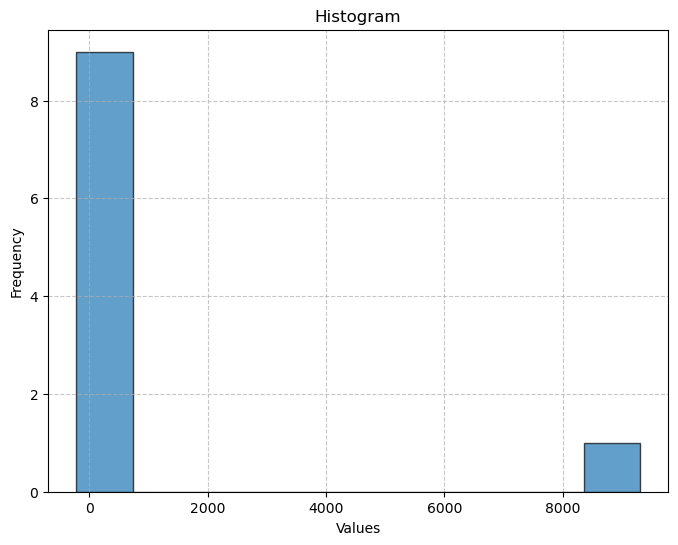

In [14]:
viz = Visualizations(results)

viz.histogram()

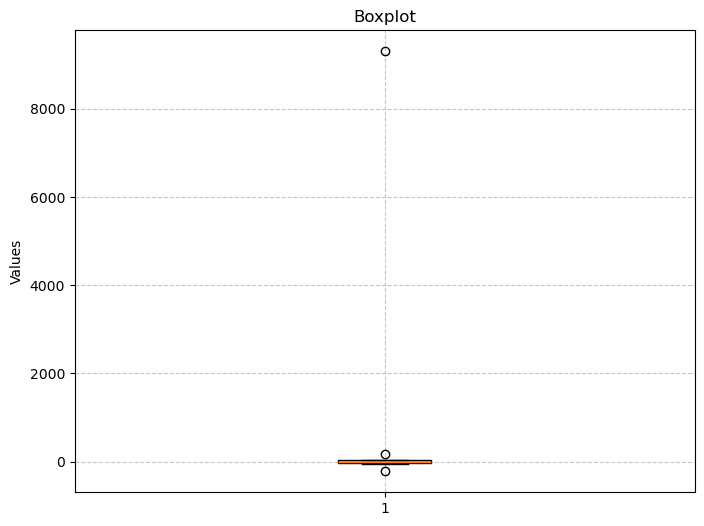

: 

In [17]:
viz.boxplot()